# Projeto Final - Introdução à Ciência de Dados
**Alunas:** Aline Manhães e Maria Luiza Ferreira


**Tema:** Redes sociais e saúde mental: um estudo baseado em dados

**Colab:** [Link](https://colab.research.google.com/drive/1ZRtIqva0jbRNYi9xtrZF_58S3io-Fpal#scrollTo=azW7kvoJTkRT)

**Vídeo:** [Disponível aqui](https://youtu.be/ySKHoQJkb7U?si=rwAy4GijZnCWo2eW)

# Introdução

O objetivo desse trabalho é, a partir das ferramentas ensinadas na disciplina de Introdução à Ciência de Dados, responder ao seguinte problema:

"O vício em redes sociais em jovens está relacionado com problemas saúde mental, horas de sono diárias? O tipo da rede social influencia no nível dos problemas gerados? O nível de saúde mental de um jovem está relacionado com o seu vício nas redes, quantidade de horas por dia de redes sociais, horas de sono diárias e desempenho escolar?".



# Definição do Problema

 Segundo artigo de 2024 da fundação Annie E. Casey, cerca de 65% indivíduos da geração Z - nascidos entre 1997 e 2012 - experienciaram problemas de saúde mental nos últimos dois anos e a mesma geração é cerca de 80% mais provável de reportar estar lidando com ansiedade ou depressão do que as outras. Uma das principais razões citadas é o uso excessivo de redes sociais. Por isso, nesse estudo, buscamos entender as possíveis consequências desses vícios: se geram resultados negativos no campo da saúde mental. Além disso, surgem duas questões:
- qual a probabilidade de alguém que passa muito tempo nas redes sofrer impactos em sua saúde mental?;
- se o tipo da rede social/plataforma utilizada afeta o tipo e o nível das consequências.

A fim de analisar de forma mais precisa, fixaremos o nosso campo de estudos desse problema apenas em jovens, que são o grupo etário que tende a ser mais afetado por essa questão, devido a sua facilidade na utilização de eletrônicos e por estarem sempre antenados em novidades que acontecem na internet, incluindo de novas redes sociais.

Utilizaremos a seguinte [base de dados](https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships) e analisando variáveis como idade, gênero, nível de escolaridade, país, tipo da rede social utilizada e quantidade de horas diárias, buscamos concluir se esse conjunto de variáveis está relacionado com o desempenho afetado de jovens em vício nas redes e em sua saúde mental.



Hipótese inicial: acreditamos que há uma relação entre o tipo da rede social e seu nível de vício com o efeito negativo em relacionamentos, saúde mental e performance nos estudos, de forma que, quanto maior o vício em determinadas redes, pior se comportam esses campos da vida. Há redes sociais que exercem um efeito ainda mais negativo em jovens, devido a comparações excessivas que são geradas por um padrão de vida inalcançável que é divulgado.

Também acreditamos que todas essas variáveis se relacionam entre si, de forma que a quantidade de horas diárias em redes sociais, horas de sono, tipo de rede social, saúde mental, entre outras, afetam diretamente o nível do vício que uma pessoa possui.

# Descrição do Conjunto de Dados

Conforme mencionado anteriormente, a base de dados a ser utilizada pode ser encontrada neste [link](https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships).

Este conjunto de dados reune informações de 2025 de estudantes jovens, entre 16 e 25 anos, que estejam no ensino médio, graduação ou pós-graduação em países variados.

Em sua pesquisa, para cada estudante, foram coletados dados de idade, gênero, nível acadêmico, país, horas médias diárias de uso de redes sociais, plataforma mais utilizada, se o uso de redes gera impacto nos estudos, horas de sono média diárias, auto-avaliação da sua saúde mental, status de relacionamento, quantidade de conflitos de relacionamento devido às redes e auto-avaliação do seu nível de vício em redes sociais.

# Metodologia

1- Aplicaremos dois métodos preditivos em dois contextos diferentes:
* KNN e Floresta Aleatória para prever nível de vício (Addicted_Score);
* KNN e Floresta Aleatória para prever nível de saúde mental (Mental_Health_Score).

Escolhemos os dois classificadores detalhados acima pois eles possuem métodos de aplicação bem distintos.

2- Para fazermos o melhor uso destes dois métodos, aplicaremos GridSearch. Assim, no KNN obteremos o melhor K e em Floresta Aleatória obteremos o melhor modelo.

3- Avaliaremos também a influência das variáveis em cada um dos dois contextos onde Floresta Aleatória será aplicada. Na hipótese dos resultados serem muito bons, removeremos a variável de maior influência, a fim de avaliar se o desempenho diminui ao classificar apenas com as outras variáveis, ou seja, se a relação entre o target e as variáveis está sendo determinada somente por uma variável de maior importância. É importante dizer que o mesmo não será aplicado no KNN, pois ele é baseado em distância, calculada utilizando todas as características da mesma forma, portanto ele apenas verifica quais pontos estão mais próximos. Já as Árvores de Decisão dividem os casos com base na importância de uma característica.

4- Buscaremos verificar se há correlação entre saúde mental e nível de vício em redes sociais.

5- Aplicaremos funcionalidades básicas da biblioteca Pandas para encontrar dados interessantes acerca da base de dados, como redes sociais mais usadas por pessoas com mais vício.

# Prática

## Classificadores

### Preparação

Primeiramente, na nossa preparação, precisamos importar as bibliotecas que serão utilizadas, ler a nossa base de dados, transformar os dados não numéricos em labels numéricas e tirar colunas da base que não vão ter relevância no processo de classificação, como a Student_ID.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv('socialmediaaddiction.csv')
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [ ]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Academic_Level'] = label_encoder.fit_transform(df['Academic_Level'])
df['Country'] = label_encoder.fit_transform(df['Country'])
df['Most_Used_Platform'] = label_encoder.fit_transform(df['Most_Used_Platform'])
df['Relationship_Status'] = label_encoder.fit_transform(df['Relationship_Status'])
df['Affects_Academic_Performance'] = label_encoder.fit_transform(df['Affects_Academic_Performance'])
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,0,2,10,5.2,1,1,6.5,6,1,3,8
1,2,22,1,0,39,2.1,7,0,7.5,8,2,0,3
2,3,20,0,2,102,6.0,6,1,5.0,5,0,4,9
3,4,18,1,1,101,3.0,11,0,7.0,7,2,1,4
4,5,21,1,0,18,4.5,0,1,6.0,6,1,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,0,2,44,4.7,6,0,7.2,7,1,2,5
701,702,23,1,0,82,6.8,1,1,5.9,4,2,5,9
702,703,21,0,2,20,5.6,9,1,6.7,6,1,3,7
703,704,24,1,0,46,4.3,7,0,7.5,8,2,2,4


In [ ]:
df.drop('Student_ID', axis=1, inplace = True)

### Vício

Começaremos analisando o nível de vício como target nos classificadores.

Agora, definiremos os nossos grupos de pessoas (target) nos baseando no Addicted_Score e nos seguintes intervalos de valores:



*   [0 , 3]: uso abaixo da média
*   ]3 , 6]: nível médio de vicío
*   ]6 , 10]: vicío elevado








In [ ]:
df_vicio = df.copy()

for i in df_vicio['Addicted_Score']:
  if i <= 3:
    df_vicio['Addicted_Score'] = df_vicio['Addicted_Score'].replace(i, "0")
  elif i <= 6:
    df_vicio['Addicted_Score'] = df_vicio['Addicted_Score'].replace(i, "1")
  else:
    df_vicio['Addicted_Score'] = df_vicio['Addicted_Score'].replace(i, "2")

df_vicio

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,6,1,3,2
1,22,1,0,39,2.1,7,0,7.5,8,2,0,0
2,20,0,2,102,6.0,6,1,5.0,5,0,4,2
3,18,1,1,101,3.0,11,0,7.0,7,2,1,1
4,21,1,0,18,4.5,0,1,6.0,6,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
700,20,0,2,44,4.7,6,0,7.2,7,1,2,1
701,23,1,0,82,6.8,1,1,5.9,4,2,5,2
702,21,0,2,20,5.6,9,1,6.7,6,1,3,2
703,24,1,0,46,4.3,7,0,7.5,8,2,2,1


Pronto! Agora todas as colunas estão prontas. Aqui ocorre a definição do target e a retirada dele da base de dados.

In [ ]:
y = df_vicio['Addicted_Score']
X = df_vicio.drop('Addicted_Score', axis=1)

#### KNN

O primeiro classificador a ser aplicado será o KNN.

Começamos separando os conjuntos de treino e teste e normalizando os valores das colunas, visto que o KNN necessita dessa peculiariadade para utilizar as variáveis na mesma intensidade ao produzir sua análise. A escolha de 25% para o conjunto de teste se deu devido ao que foi exemplificado nos Colabs da disciplina.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

Conforme mencionado na seção de Metodologia, utilizaremos GridSearch para tentarmos encontrar o melhor K.

In [ ]:
params = {'n_neighbors': np.arange(1, 46)}

clf = GridSearchCV(KNeighborsClassifier(), params, n_jobs = -1)
clf.fit(X_train_scaled, y_train);

X_test =  scaler.transform(X_test)
y_predicted = clf.predict(X_test)

clf.best_params_

{'n_neighbors': np.int64(1)}

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.97      0.99        68
           2       0.99      1.00      1.00       104

    accuracy                           0.99       177
   macro avg       0.94      0.99      0.96       177
weighted avg       0.99      0.99      0.99       177



De acordo com os testes realizados acima, o melhor K possui valor 1. Agora, aplicaremos KNN de fato em nossa base de dados com o valor K encontrado. Começamos separando os conjuntos de treino e teste e normalizando os valores das colunas, igual feito anteriormente.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [ ]:
k = 1
model = KNeighborsClassifier(n_neighbors = k)
model.fit(X_train_scaled, y_train);

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled);

In [ ]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Classificador = {acuracia:.4f}")

Acurácia do Classificador = 0.9944


Nosso classificador gerou uma acurácia de 99,44%, o que é excelente! Abaixo podem ser visualizados os valores resposta do conjunto de teste e o que foi previsto pelo classificador.

In [ ]:
y_test.values

array(['2', '1', '1', '1', '1', '1', '1', '2', '1', '2', '2', '2', '1',
       '2', '2', '2', '2', '2', '1', '2', '1', '2', '1', '1', '2', '1',
       '2', '2', '1', '2', '1', '2', '2', '2', '1', '2', '1', '1', '2',
       '2', '1', '2', '1', '2', '1', '1', '2', '2', '1', '1', '1', '1',
       '1', '2', '1', '1', '1', '1', '2', '2', '2', '1', '2', '1', '1',
       '1', '2', '1', '1', '2', '0', '2', '2', '1', '1', '2', '2', '2',
       '2', '2', '2', '1', '2', '2', '1', '2', '2', '1', '2', '2', '2',
       '1', '2', '2', '2', '2', '1', '2', '2', '2', '2', '1', '1', '2',
       '2', '2', '2', '2', '1', '1', '2', '2', '2', '1', '1', '1', '2',
       '0', '2', '2', '2', '2', '2', '2', '2', '1', '2', '2', '2', '1',
       '2', '1', '1', '2', '2', '2', '2', '2', '1', '2', '1', '1', '0',
       '2', '2', '1', '2', '1', '2', '2', '2', '2', '2', '1', '2', '2',
       '1', '1', '1', '2', '2', '1', '2', '2', '1', '1', '2', '2', '1',
       '2', '2', '1', '2', '2', '2', '2', '1'], dtype=object)

In [ ]:
y_pred

array(['2', '1', '1', '1', '1', '1', '1', '2', '1', '2', '2', '2', '1',
       '2', '2', '2', '2', '2', '1', '2', '1', '2', '1', '1', '2', '1',
       '2', '2', '1', '2', '1', '2', '2', '2', '1', '2', '1', '1', '2',
       '2', '1', '2', '1', '2', '1', '1', '2', '2', '1', '1', '1', '1',
       '1', '2', '1', '1', '1', '1', '2', '2', '2', '1', '2', '1', '1',
       '1', '2', '1', '1', '2', '0', '2', '2', '1', '1', '2', '2', '2',
       '2', '2', '2', '1', '2', '2', '1', '2', '2', '1', '2', '2', '2',
       '1', '2', '2', '2', '2', '1', '2', '2', '2', '2', '1', '1', '2',
       '2', '2', '2', '2', '1', '1', '2', '2', '2', '1', '1', '1', '2',
       '1', '2', '2', '2', '2', '2', '2', '2', '1', '2', '2', '2', '1',
       '2', '1', '1', '2', '2', '2', '2', '2', '1', '2', '1', '1', '0',
       '2', '2', '1', '2', '1', '2', '2', '2', '2', '2', '1', '2', '2',
       '1', '1', '1', '2', '2', '1', '2', '2', '1', '1', '2', '2', '1',
       '2', '2', '1', '2', '2', '2', '2', '1'], dtype=object)

#### Floresta Aleatória

O segundo classificador a ser aplicado será Floresta Aleatória.

Começamos separando os conjuntos de treino e teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Serão geradas  combinações de 72 modelos com bases nas opções de parâmetros definidos e posterior validação com 5 folds para retornar o melhor modelo. Os parâmetros escolhidos foram:



- ``n_estimators``: número de árvores na floresta
- ``max_depth``: profundidade máxima de cada árvore da floresta
- ``max_features``: tamanho da amostra aleatória de características para o processo de divisão de cada nó de cada árvore de decisão
- ``max_samples``: tamanho da amostra (relativo ao tamanho do conjunto de treinamento) para treinar cada Árvore de Decisão da Floresta.


In [ ]:
params = {'n_estimators': [100, 500],
          'max_depth': [2, 4, 6, 8],
          'max_features': ['sqrt', 'log2', 1.0],
          'max_samples': [0.2, 0.6, 1.0]};

grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid = params, cv = 5, n_jobs = -1, verbose = 9);
grid_search.fit(X_train, y_train);

Fitting 5 folds for each of 72 candidates, totalling 360 fits


A seguir, será realizada a predição dos elementos e a avaliação do classificador treinado.



In [ ]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test, y_pred))
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Classificador = {acuracia:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.99      0.99        68
           2       0.99      1.00      1.00       106

    accuracy                           0.99       177
   macro avg       1.00      1.00      1.00       177
weighted avg       0.99      0.99      0.99       177

Acurácia do Classificador = 0.9944


Nosso classificador gerou uma acurácia de 99,44%, o que é excelente! Abaixo podem ser visualizados os valores resposta do conjunto de teste e o que foi previsto pelo classificador.

In [ ]:
y_test.values

array(['1', '2', '1', '2', '1', '2', '0', '1', '1', '2', '2', '2', '2',
       '2', '1', '1', '1', '1', '2', '2', '1', '2', '2', '2', '1', '1',
       '2', '2', '1', '2', '2', '2', '2', '1', '2', '2', '2', '2', '2',
       '1', '2', '1', '2', '2', '2', '1', '2', '1', '1', '2', '2', '1',
       '1', '1', '2', '2', '1', '2', '2', '2', '1', '1', '1', '2', '1',
       '1', '2', '1', '2', '2', '2', '2', '1', '1', '1', '2', '1', '2',
       '2', '2', '2', '1', '2', '2', '2', '1', '2', '1', '2', '1', '1',
       '2', '2', '2', '1', '2', '1', '1', '2', '1', '1', '0', '1', '2',
       '1', '1', '2', '1', '2', '1', '2', '1', '1', '2', '2', '1', '2',
       '1', '1', '2', '2', '2', '2', '2', '2', '2', '2', '1', '0', '1',
       '2', '2', '1', '2', '2', '2', '1', '2', '2', '1', '1', '1', '2',
       '2', '2', '1', '1', '2', '1', '2', '2', '2', '2', '2', '1', '2',
       '2', '1', '2', '2', '2', '2', '2', '2', '2', '2', '2', '1', '2',
       '1', '2', '2', '2', '2', '2', '1', '2'], dtype=object)

In [ ]:
y_pred

array(['1', '2', '1', '2', '1', '2', '0', '1', '1', '2', '2', '2', '2',
       '2', '1', '1', '1', '2', '2', '2', '1', '2', '2', '2', '1', '1',
       '2', '2', '1', '2', '2', '2', '2', '1', '2', '2', '2', '2', '2',
       '1', '2', '1', '2', '2', '2', '1', '2', '1', '1', '2', '2', '1',
       '1', '1', '2', '2', '1', '2', '2', '2', '1', '1', '1', '2', '1',
       '1', '2', '1', '2', '2', '2', '2', '1', '1', '1', '2', '1', '2',
       '2', '2', '2', '1', '2', '2', '2', '1', '2', '1', '2', '1', '1',
       '2', '2', '2', '1', '2', '1', '1', '2', '1', '1', '0', '1', '2',
       '1', '1', '2', '1', '2', '1', '2', '1', '1', '2', '2', '1', '2',
       '1', '1', '2', '2', '2', '2', '2', '2', '2', '2', '1', '0', '1',
       '2', '2', '1', '2', '2', '2', '1', '2', '2', '1', '1', '1', '2',
       '2', '2', '1', '1', '2', '1', '2', '2', '2', '2', '2', '1', '2',
       '2', '1', '2', '2', '2', '2', '2', '2', '2', '2', '2', '1', '2',
       '1', '2', '2', '2', '2', '2', '1', '2'], dtype=object)

Como a nossa acurácia foi extremamente alta, faremos uma análise de quais características, de forma unitária, estão afetando mais os resultados, de modo a testar o comportamento do classificador após a sua retirada.

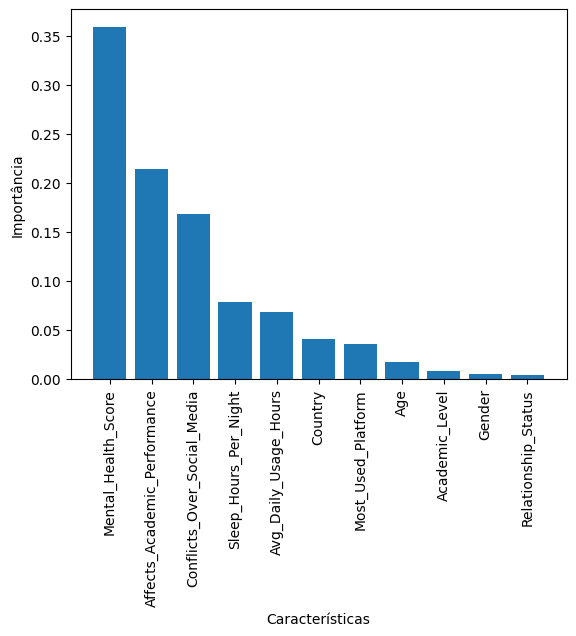

In [ ]:
importances = grid_search.best_estimator_.feature_importances_
order = np.argsort(importances)[::-1]

plt.bar(X.columns[order], importances[order])
plt.ylabel('Importância')
plt.xlabel('Características')
plt.xticks(rotation=90);

Agora removeremos a variável que foi considerada a principal, com base na utilização do estimador de importância. Portanto, removeremos "Mental_Health_Score" para verificar se as outras variáveis ainda geram um bom classificador. Repetiremos todo o processo que foi realizado acima.

In [ ]:
y2 = df_vicio['Addicted_Score']
X2 = df_vicio.drop(['Addicted_Score', 'Mental_Health_Score'], axis=1)

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

In [ ]:
params = {'n_estimators': [100, 500],
          'max_depth': [2, 4, 6, 8],
          'max_features': ['sqrt', 'log2', 1.0],
          'max_samples': [0.2, 0.6, 1.0]};

grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid = params, cv = 5, n_jobs = -1, verbose = 9);
grid_search.fit(X2_train, y2_train);


Fitting 5 folds for each of 72 candidates, totalling 360 fits


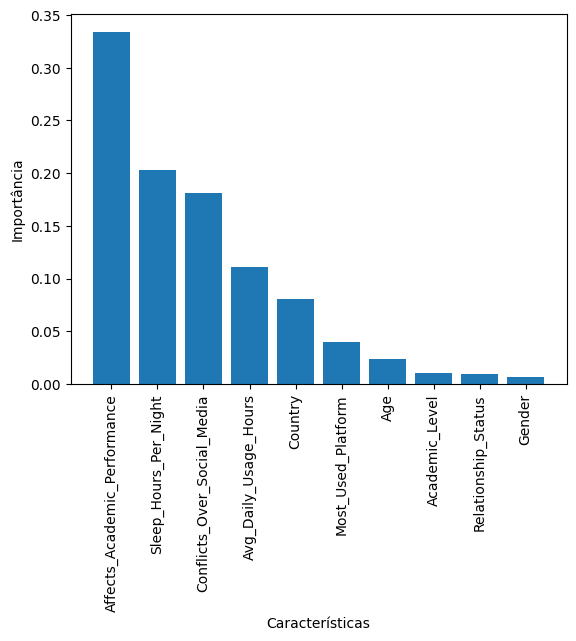

In [ ]:
importances = grid_search.best_estimator_.feature_importances_
order = np.argsort(importances)[::-1]

plt.bar(X2.columns[order], importances[order])
plt.ylabel('Importância')
plt.xlabel('Características')
plt.xticks(rotation=90);

In [ ]:
y2_pred = grid_search.predict(X2_test)

print(classification_report(y2_test, y2_pred))
acuracia = accuracy_score(y2_test, y2_pred)
print(f"Acurácia do Classificador = {acuracia:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.99      0.97      0.98        68
           2       0.98      0.99      0.99       106

    accuracy                           0.98       177
   macro avg       0.99      0.99      0.99       177
weighted avg       0.98      0.98      0.98       177

Acurácia do Classificador = 0.9831


Considerando que, após a retirada de "Mental_Health_Score", a perda de acurácia foi pequena e o resultado foi ótimo. Chegamos à suposição de que a maior parte dos dados possui uma correlação forte, por isso a acurácia acaba sendo tão satisfatória.

### Saúde Mental

Analisaremos o nível de saúde mental como target nos classificadores.

Agora na preparação para colocar vício como target, definimos os nossos grupos de pessoas baseando-se no Mental_Health_Score:

*   [0 , 3]: Sáude mental baixa
*   ]3 , 6]: Saúde mental na média
*   ]6 , 10]: Saúde mental boa







In [ ]:
df_saude_mental = df.copy()

for i in df_saude_mental['Mental_Health_Score']:
  if i <= 3:
    df_saude_mental['Mental_Health_Score'] = df_saude_mental['Mental_Health_Score'].replace(i, "0")
  elif i <= 6:
    df_saude_mental['Mental_Health_Score'] = df_saude_mental['Mental_Health_Score'].replace(i, "1")
  else:
    df_saude_mental['Mental_Health_Score'] = df_saude_mental['Mental_Health_Score'].replace(i, "2")

df_saude_mental

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,1,1,3,8
1,22,1,0,39,2.1,7,0,7.5,2,2,0,3
2,20,0,2,102,6.0,6,1,5.0,1,0,4,9
3,18,1,1,101,3.0,11,0,7.0,2,2,1,4
4,21,1,0,18,4.5,0,1,6.0,1,1,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
700,20,0,2,44,4.7,6,0,7.2,2,1,2,5
701,23,1,0,82,6.8,1,1,5.9,1,2,5,9
702,21,0,2,20,5.6,9,1,6.7,1,1,3,7
703,24,1,0,46,4.3,7,0,7.5,2,2,2,4


Ocorre a definição do target e a retirada dele da base de dados.

In [ ]:
y = df_saude_mental['Mental_Health_Score']
X = df_saude_mental.drop('Mental_Health_Score', axis=1)

#### KNN

O primeiro classificador a ser aplicado será o KNN.

Começamos separando os conjuntos de treino e teste e normalizando os valores das colunas, visto que o KNN necessita dessa peculiariadade para utilizar as variáveis na mesma intensidade ao produzir sua análise.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

Conforme mencionado na seção de Metodologia, utilizaremos GridSearch para tentarmos encontrar o melhor K.

In [ ]:
params = {'n_neighbors': np.arange(1, 46)}

from sklearn.model_selection import GridSearchCV

clf = GridSearchCV(KNeighborsClassifier(), params, n_jobs = -1)
clf.fit(X_train_scaled, y_train);

X_test =  scaler.transform(X_test)
y_predicted = clf.predict(X_test)

clf.best_params_

{'n_neighbors': np.int64(1)}

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           1       0.97      1.00      0.99       107
           2       1.00      0.96      0.98        70

    accuracy                           0.98       177
   macro avg       0.99      0.98      0.98       177
weighted avg       0.98      0.98      0.98       177



De acordo com os testes realizados acima, o melhor K possui valor 1. Agora, aplicaremos KNN de fato em nossa base de dados com o valor K encontrado. Começamos separando os conjuntos de treino e teste e normalizando os valores das colunas, igual feito anteriormente.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [ ]:
k = 1
model = KNeighborsClassifier(n_neighbors = k)
model.fit(X_train_scaled, y_train);

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled);

In [ ]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Classificador = {acuracia:.4f}")

Acurácia do Classificador = 1.0000


Nosso classificador gerou uma acurácia de 100%, o que é extremamente alto! Abaixo podem ser visualizados os valores resposta do conjunto de teste e o que foi previsto pelo classificador.

In [ ]:
y_test.values

array(['1', '1', '1', '2', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '2', '1', '1', '2', '2', '2', '1', '1', '1', '1', '2', '2', '2',
       '1', '1', '2', '2', '1', '2', '2', '1', '2', '1', '2', '1', '1',
       '1', '1', '2', '1', '1', '1', '2', '1', '2', '2', '1', '2', '1',
       '1', '1', '1', '1', '2', '2', '2', '2', '1', '2', '2', '1', '1',
       '2', '2', '2', '1', '2', '1', '1', '1', '2', '1', '2', '1', '2',
       '2', '1', '1', '1', '1', '1', '2', '2', '1', '2', '1', '2', '1',
       '1', '2', '1', '1', '2', '2', '1', '1', '1', '1', '1', '2', '1',
       '1', '2', '2', '1', '2', '2', '1', '1', '2', '1', '1', '2', '1',
       '2', '1', '1', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2',
       '1', '1', '2', '1', '1', '2', '1', '1', '1', '2', '1', '1', '1',
       '1', '2', '2', '2', '2', '2', '1', '1', '1', '1', '2', '1', '2',
       '2', '2', '2', '2', '1', '2', '1', '1', '1', '2', '2', '1', '1',
       '2', '1', '1', '1', '2', '1', '2', '1'], dtype=object)

In [ ]:
y_pred

array(['1', '1', '1', '2', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '2', '1', '1', '2', '2', '2', '1', '1', '1', '1', '2', '2', '2',
       '1', '1', '2', '2', '1', '2', '2', '1', '2', '1', '2', '1', '1',
       '1', '1', '2', '1', '1', '1', '2', '1', '2', '2', '1', '2', '1',
       '1', '1', '1', '1', '2', '2', '2', '2', '1', '2', '2', '1', '1',
       '2', '2', '2', '1', '2', '1', '1', '1', '2', '1', '2', '1', '2',
       '2', '1', '1', '1', '1', '1', '2', '2', '1', '2', '1', '2', '1',
       '1', '2', '1', '1', '2', '2', '1', '1', '1', '1', '1', '2', '1',
       '1', '2', '2', '1', '2', '2', '1', '1', '2', '1', '1', '2', '1',
       '2', '1', '1', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2',
       '1', '1', '2', '1', '1', '2', '1', '1', '1', '2', '1', '1', '1',
       '1', '2', '2', '2', '2', '2', '1', '1', '1', '1', '2', '1', '2',
       '2', '2', '2', '2', '1', '2', '1', '1', '1', '2', '2', '1', '1',
       '2', '1', '1', '1', '2', '1', '2', '1'], dtype=object)

#### Floresta Aleatória

O segundo classificador a ser aplicado será Floresta Aleatória.

Começamos separando os conjuntos de treino e teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Serão geradas  combinações de 72 modelos com bases nas opções de parâmetros definidos e posterior validação com 5 folds para retornar o melhor modelo. Os parâmetros escolhidos foram:



- ``n_estimators``: número de árvores na floresta
- ``max_depth``: profundidade máxima de cada árvore da floresta
- ``max_features``: tamanho da amostra aleatória de características para o processo de divisão de cada nó de cada árvore de decisão
- ``max_samples``: tamanho da amostra (relativo ao tamanho do conjunto de treinamento) para treinar cada Árvore de Decisão da Floresta.


In [ ]:
params = {'n_estimators': [100, 500],
          'max_depth': [2, 4, 6, 8],
          'max_features': ['sqrt', 'log2', 1.0],
          'max_samples': [0.2, 0.6, 1.0]};

grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid = params, cv = 5, n_jobs = -1, verbose = 9);
grid_search.fit(X_train, y_train);


Fitting 5 folds for each of 72 candidates, totalling 360 fits


A seguir, será realizada a predição dos elementos e a avaliação do classificador treinado.



In [ ]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test, y_pred))
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Classificador = {acuracia:.4f}")

              precision    recall  f1-score   support

           1       1.00      0.99      1.00       110
           2       0.99      1.00      0.99        67

    accuracy                           0.99       177
   macro avg       0.99      1.00      0.99       177
weighted avg       0.99      0.99      0.99       177

Acurácia do Classificador = 0.9944


Nosso classificador gerou uma acurácia de 99,44%, o que é excelente! Abaixo podem ser visualizados os valores resposta do conjunto de teste e o que foi previsto pelo classificador.

In [ ]:
y_test.values

array(['2', '1', '2', '1', '2', '1', '2', '2', '2', '1', '1', '1', '1',
       '1', '2', '2', '2', '1', '1', '1', '2', '1', '1', '1', '2', '2',
       '1', '1', '2', '1', '1', '1', '1', '2', '1', '1', '1', '1', '1',
       '2', '1', '2', '1', '1', '1', '2', '1', '1', '2', '1', '1', '1',
       '2', '2', '1', '1', '2', '1', '1', '1', '2', '2', '2', '1', '1',
       '2', '1', '2', '1', '1', '1', '1', '2', '2', '2', '1', '2', '1',
       '1', '1', '1', '2', '1', '1', '1', '2', '1', '2', '1', '2', '2',
       '1', '1', '1', '2', '1', '2', '2', '1', '2', '2', '2', '2', '1',
       '2', '2', '1', '2', '1', '2', '1', '2', '2', '1', '1', '2', '1',
       '2', '2', '1', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2',
       '1', '1', '2', '1', '1', '1', '2', '1', '1', '2', '2', '2', '1',
       '1', '1', '2', '2', '1', '2', '1', '1', '1', '1', '1', '2', '1',
       '1', '2', '1', '1', '1', '1', '1', '1', '1', '1', '1', '2', '1',
       '2', '1', '1', '1', '1', '1', '2', '1'], dtype=object)

In [ ]:
y_pred

array(['2', '1', '2', '1', '2', '1', '2', '2', '2', '1', '1', '1', '1',
       '1', '2', '2', '2', '2', '1', '1', '2', '1', '1', '1', '2', '2',
       '1', '1', '2', '1', '1', '1', '1', '2', '1', '1', '1', '1', '1',
       '2', '1', '2', '1', '1', '1', '2', '1', '1', '2', '1', '1', '1',
       '2', '2', '1', '1', '2', '1', '1', '1', '2', '2', '2', '1', '1',
       '2', '1', '2', '1', '1', '1', '1', '2', '2', '2', '1', '2', '1',
       '1', '1', '1', '2', '1', '1', '1', '2', '1', '2', '1', '2', '2',
       '1', '1', '1', '2', '1', '2', '2', '1', '2', '2', '2', '2', '1',
       '2', '2', '1', '2', '1', '2', '1', '2', '2', '1', '1', '2', '1',
       '2', '2', '1', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2',
       '1', '1', '2', '1', '1', '1', '2', '1', '1', '2', '2', '2', '1',
       '1', '1', '2', '2', '1', '2', '1', '1', '1', '1', '1', '2', '1',
       '1', '2', '1', '1', '1', '1', '1', '1', '1', '1', '1', '2', '1',
       '2', '1', '1', '1', '1', '1', '2', '1'], dtype=object)

Como a nossa acurácia foi extremamente alta, faremos uma análise de quais características, de forma unitária, estão afetando mais os resultados, de modo a testar o comportamento do classificador após a sua retirada.

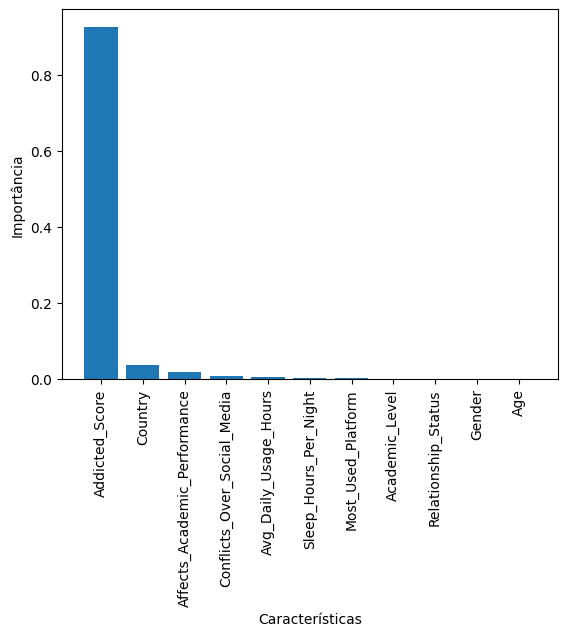

In [ ]:
importances = grid_search.best_estimator_.feature_importances_
order = np.argsort(importances)[::-1]

plt.bar(X.columns[order], importances[order])
plt.ylabel('Importância')
plt.xlabel('Características')
plt.xticks(rotation=90);

Agora removeremos a variável que foi considerada a principal, com base na utilização do estimador de importância. Portanto, removeremos "Addicted_Score" para verificar se as outras variáveis ainda geram um bom classificador. Repetiremos todo o processo que foi realizado acima.

In [ ]:
y2 = df_saude_mental['Mental_Health_Score']
X2 = df_saude_mental.drop(['Mental_Health_Score', 'Addicted_Score'], axis=1)

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

In [ ]:
params = {'n_estimators': [100, 500],
          'max_depth': [2, 4, 6, 8],
          'max_features': ['sqrt', 'log2', 1.0],
          'max_samples': [0.2, 0.6, 1.0]};

grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid = params, cv = 5, n_jobs = -1, verbose = 9);
grid_search.fit(X2_train, y2_train);


Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [ ]:
y2_pred = grid_search.predict(X2_test)

print(classification_report(y2_test, y2_pred))
acuracia = accuracy_score(y2_test, y2_pred)
print(f"Acurácia do Classificador = {acuracia:.4f}")

              precision    recall  f1-score   support

           1       0.98      1.00      0.99       110
           2       1.00      0.97      0.98        67

    accuracy                           0.99       177
   macro avg       0.99      0.99      0.99       177
weighted avg       0.99      0.99      0.99       177

Acurácia do Classificador = 0.9887


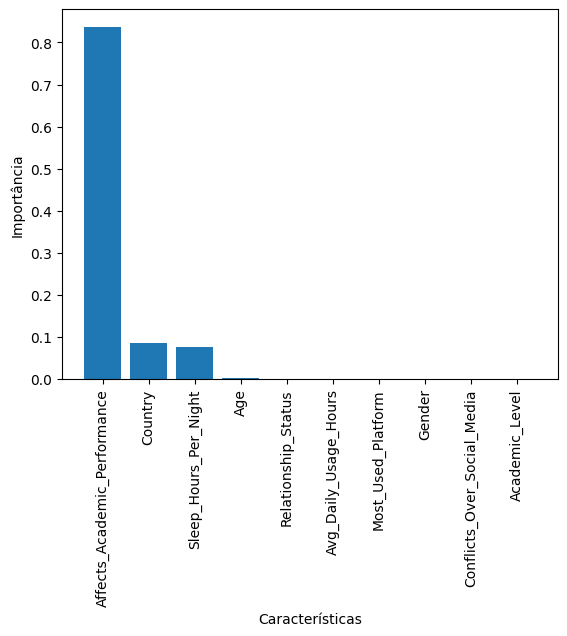

In [ ]:
importances = grid_search.best_estimator_.feature_importances_
order = np.argsort(importances)[::-1]

plt.bar(X2.columns[order], importances[order])
plt.ylabel('Importância')
plt.xlabel('Características')
plt.xticks(rotation=90);

Considerando que, após a retirada de "Addicted_Score", a perda de acurácia foi pequena e o resultado foi ótimo. Chegamos à suposição de que a maior parte dos dados possui uma correlação forte, por isso a acurácia acaba sendo tão satisfatória.

## Correlação

Agora tentaremos responder a nossa suposição da correlação entre as varíaveis ser forte ou não, principalmente nas referentes a vícios e saúde mental, e também analisar padrões comportamentais dentre os grupos de pesssoas.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('socialmediaaddiction.csv')

Precisamos transformar todos os dados em valores numéricos para aplicar a função que mede a correlação.

In [ ]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Academic_Level'] = label_encoder.fit_transform(df['Academic_Level'])
df['Country'] = label_encoder.fit_transform(df['Country'])
df['Most_Used_Platform'] = label_encoder.fit_transform(df['Most_Used_Platform'])
df['Relationship_Status'] = label_encoder.fit_transform(df['Relationship_Status'])
df['Affects_Academic_Performance'] = label_encoder.fit_transform(df['Affects_Academic_Performance'])

Aplicaremos a função `corr()` para medir a correlação entre as variáveis da nossa base de dados. Os resultados variam entre -1 e 1 e possuem o seguinte significado:
- `1`: correlação positiva perfeita, as duas variáveis crescem juntas
- `0`: não há relação linear
- `-1`: correlação negativa perfeita, quando uma variável cresce a outra decresce

In [ ]:
df.corr()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,1.000000,0.222306,-0.001087,-0.054528,0.033372,0.267524,0.085917,0.053780,0.173793,-0.055037,0.219610,0.173258,0.041637
Age,0.222306,1.000000,0.494710,-0.776967,-0.054005,-0.113682,0.088811,-0.137140,0.125265,0.160278,-0.048954,-0.184482,-0.166396
Gender,-0.001087,0.494710,1.000000,-0.660046,-0.102901,-0.073582,0.134973,-0.024736,0.046946,0.046534,-0.023085,-0.089126,-0.049692
Academic_Level,-0.054528,-0.776967,-0.660046,1.000000,0.111414,0.086724,-0.078314,0.036272,-0.085657,-0.084363,0.076922,0.109195,0.075543
Country,0.033372,-0.054005,-0.102901,0.111414,1.000000,0.218550,-0.033515,0.182389,-0.182285,-0.207797,0.144056,0.208445,0.221383
Avg_Daily_Usage_Hours,0.267524,-0.113682,-0.073582,0.086724,0.218550,1.000000,0.270838,0.661474,-0.790582,-0.801058,0.017616,0.804582,0.832000
Most_Used_Platform,0.085917,0.088811,0.134973,-0.078314,-0.033515,0.270838,1.000000,0.222285,-0.302133,-0.165604,-0.011359,0.169730,0.209653
Affects_Academic_Performance,0.053780,-0.137140,-0.024736,0.036272,0.182389,0.661474,0.222285,1.000000,-0.625373,-0.808921,0.115705,0.832030,0.866049
Sleep_Hours_Per_Night,0.173793,0.125265,0.046946,-0.085657,-0.182285,-0.790582,-0.302133,-0.625373,1.000000,0.707439,0.158027,-0.677266,-0.764858
Mental_Health_Score,-0.055037,0.160278,0.046534,-0.084363,-0.207797,-0.801058,-0.165604,-0.808921,0.707439,1.000000,-0.004151,-0.893572,-0.945051


Correlações que chamam atenção:
- Age e Academic_Level -0.77
- Avg_Daily_Usage_Hours e Affects_Academic_Performance: 0.66
- **Avg_Daily_Usage_Hours e Sleep_Hours_Per_Night: -0.79**
- **Avg_Daily_Usage_Hours e Mental_Health_Score: -0.80**
- **Avg_Daily_Usage_Hours e Conflicts_Over_Social_Media: 0.80**
- **Avg_Daily_Usage_Hours e Addicted_Score: 0.83**
- **Affects_Academic_Performance e Mental_Health_Score: -0.80**
- **Affects_Academic_Performance e Conflicts_Over_Social_Media: 0.83**
- **Affects_Academic_Performance e Addicted_Score: 0.86**
- **Sleep_Hours_Per_Night e Mental_Health_Score: 0.70**
- Sleep_Hours_Per_Night e Conflicts_Over_Social_Media: -0.67
- **Sleep_Hours_Per_Night e Addicted_Score: -0.76**
- **Mental_Health_Score e Conflicts_Over_Social_Media: -0.89**
- **Mental_Health_Score e Addicted_Score: -0.94**
- **Conflicts_Over_Social_Media e Addicted_Score: 0.93**


Para uma melhor visualização dessas correlações, geraremos o mapa de calor abaixo.

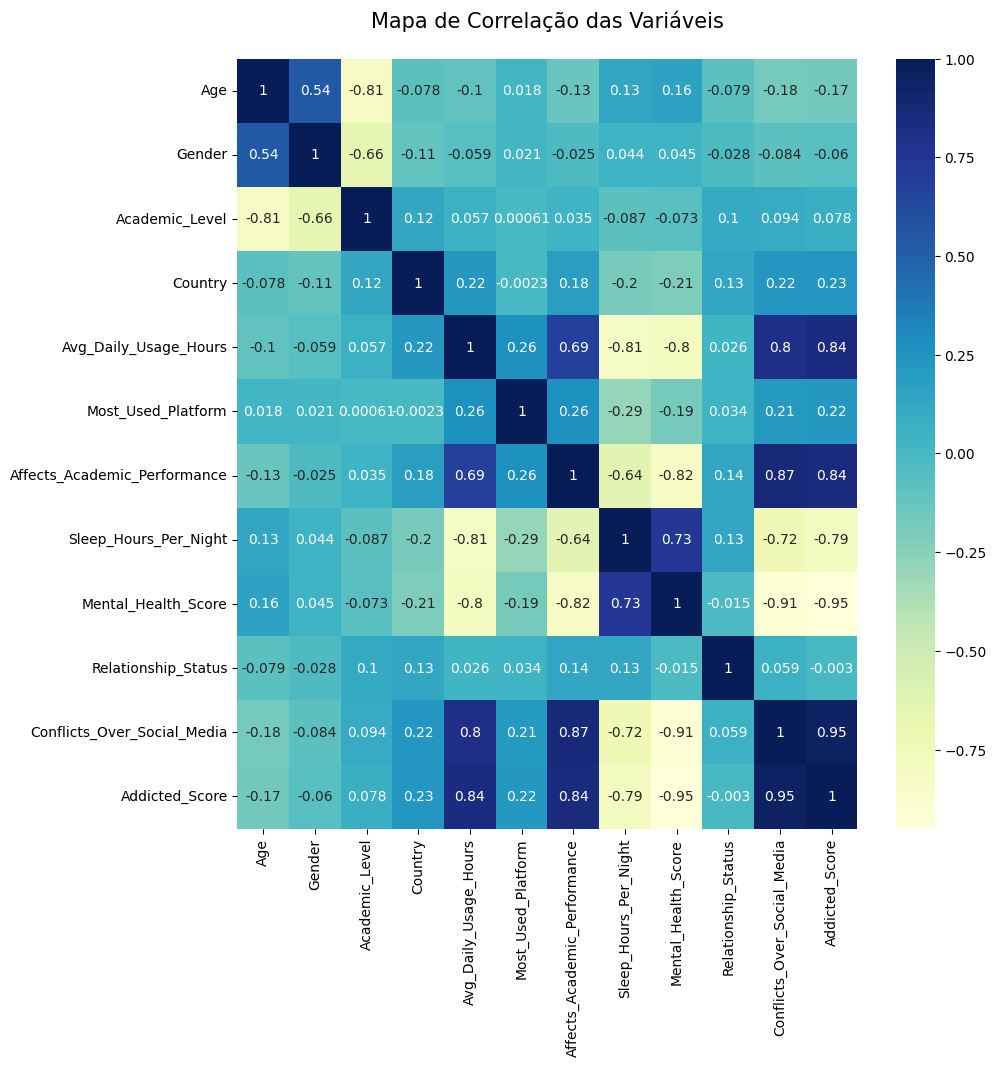

In [ ]:
df.drop("Student_ID", axis = 1).corr("spearman")
plt.figure(figsize = (10,10))
sns.heatmap(df.drop("Student_ID", axis = 1).corr("spearman"), annot = True, cmap = "YlGnBu")
plt.title("Mapa de Correlação das Variáveis\n", fontsize = 15)
plt.show()


Com base na lista acima, podemos confirmar que tanto Mental_Health_Score quanto Addicted_Score possuem múltiplas variáveis com alta correlação. Portanto, faz sentido que, mesmo ao tirar a primeira variável com maior influência, no resultado total com classificadores, a acurácia permaneça alta, ainda mais considerando que estamos usando técnicas para se obter o resultado ótimo.

## Pandas

Nessa seção, utilizaremos recursos básicos da biblioteca Pandas para encontrar dados interessantes acerca da nossa base de dados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('socialmediaaddiction.csv')

Abaixo, se encontra uma descrição geral das colunas/variáveis principais encontradas na correlação da seção anterior.
A partir de uma análise dessa tabela, podemos ver que:
- há ao menos uma pessoa que utiliza diariamente redes sociais por 8,5 horas (valor máximo encontrado) e outra que utiliza por 1,5h (valor mínimo encontrado)
- a pessoa que dorme menos tem 3,8h de sono por dia e a que dorme mais tem 9,6h
- a saúde mental média é de nível 6,23
- o nível de vício médio é 6,44
- o maior nível de vício é 9 e o menor é 2

In [ ]:
df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Addicted_Score']].describe()

,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000
mean,4.918723,6.868936,6.226950,6.436879
std,1.257395,1.126848,1.105055,1.587165
min,1.500000,3.800000,4.000000,2.000000
25%,4.100000,6.000000,5.000000,5.000000
50%,4.800000,6.900000,6.000000,7.000000
75%,5.800000,7.700000,7.000000,8.000000
max,8.500000,9.600000,9.000000,9.000000


A seguir, geramos gráficos de frequencia de nível de vício e de saúde mental.

Para o nível de vício, podemos concluir que existem 3 grupos de nível, semelhantes aos que foram utilizados para target nos classificadores, e o grupo com mais pessoas é o de alto nível de vício.

Para o nível de saúde mental, podemos concluir que ela está bem distribuída, com muitas pessoas no valor médio 6. Ainda podemos ver que não há pessoas com saúde mental menor que 4.

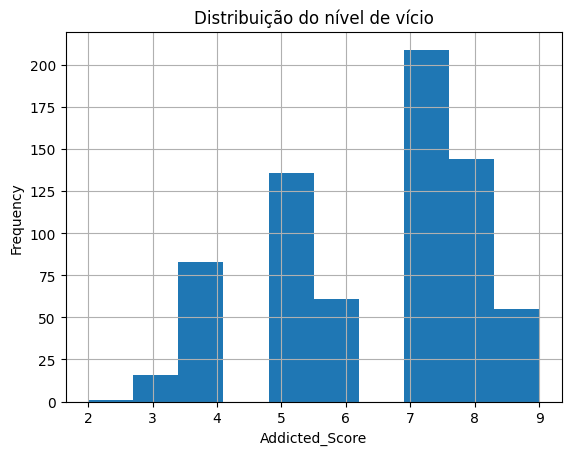

In [ ]:
df.Addicted_Score.hist()
plt.xlabel('Addicted_Score')
plt.ylabel('Frequency')
plt.title('Distribuição do nível de vício');

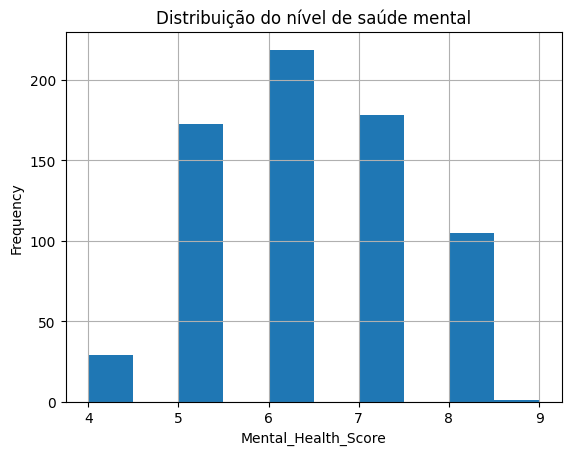

In [ ]:
df.Mental_Health_Score.hist()
plt.xlabel('Mental_Health_Score')
plt.ylabel('Frequency')
plt.title('Distribuição do nível de saúde mental');

Aqui, alteraremos o índice dos dados e faremos com que ele seja o nível de vício, a fim de facilitar nossos próximos estudos.

In [ ]:
new_df = df.copy()
new_df.set_index('Addicted_Score', inplace = True)
new_df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media
Addicted_Score,,,,,,,,,,,,
8,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3
3,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0
9,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4
4,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1
7,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2


### Plataformas

Analisaremos as principais plataformas das pessoas com maiores níveis de vício (7, 8 e 9).

Obs: os valores exibidos são em porcentagem.

In [ ]:
new_df.loc[9].Most_Used_Platform.value_counts(normalize=True) * 100

,proportion
Most_Used_Platform,
Instagram,54.545455
TikTok,36.363636
Facebook,5.454545
Snapchat,1.818182
YouTube,1.818182


In [ ]:
new_df.loc[[8, 9]].Most_Used_Platform.value_counts(normalize=True) * 100

,proportion
Most_Used_Platform,
TikTok,39.195980
Instagram,31.658291
WhatsApp,12.562814
Facebook,11.055276
Snapchat,3.015075
Twitter,2.010050
YouTube,0.502513


In [ ]:
new_df.loc[[7, 8, 9]].Most_Used_Platform.value_counts(normalize=True) * 100

,proportion
Most_Used_Platform,
Instagram,37.500000
TikTok,32.598039
WhatsApp,13.235294
Facebook,8.333333
Snapchat,2.941176
Twitter,2.696078
WeChat,1.960784
YouTube,0.735294


Concluímos que as plataformas de redes mais utilizadas por pessoas com maior vício são Instagram e TikTok, sobretudo para pessoas com nível de vício 9.

Agora analisaremos as redes mais utilizadas dentre pessoas de comportamento médio (4, 5 e 6) nas redes sociais.

In [ ]:
new_df.loc[[4, 5, 6]].Most_Used_Platform.value_counts(normalize=True) * 100

,proportion
Most_Used_Platform,
Instagram,34.285714
Facebook,31.785714
TikTok,7.500000
Twitter,6.428571
LinkedIn,6.071429
VKontakte,4.285714
KakaoTalk,4.285714
YouTube,2.500000
WeChat,2.500000


É perceptível a subida no uso de pessoas de tempo médio no Facebook e a descida daqueles que utilizam o TikTok. Apesar da mudança comportamental, o Instagram permance com alta proporção de uso.

Analisaremos, agora, as principais plataformas das pessoas com menores níveis de vício (2 e 3):

In [ ]:
new_df.loc[2].Most_Used_Platform #só existe uma pessoa com nível de vício 2

'LinkedIn'

In [ ]:
new_df.loc[[2, 3]].Most_Used_Platform.value_counts(normalize=True) * 100

,proportion
Most_Used_Platform,
LINE,70.588235
LinkedIn,23.529412
Twitter,5.882353


Concluímos que as plataformas de redes mais utilizadas por pessoas com menor vício são LINE e LinkedIn.

O gráfico abaixo exibe o nível de vício e de saúde mental médios das pessoas que utilizam cada uma das plataformas mencionadas na base de dados.

LINE e LinkedIn possuem as menores médias de vício e as maiores de saúde mental.
Em contrapartida, Snapchat, TikTok, WhatsApp e Instagram possuem as maiores médias de vício e as menores médias de saúde mental.

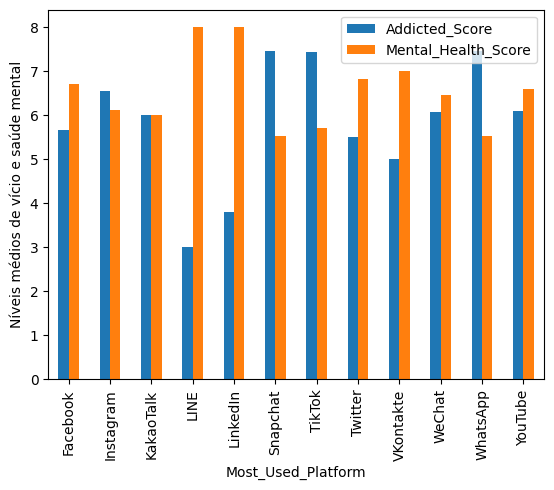

In [ ]:
df.groupby(['Most_Used_Platform'])[['Addicted_Score', 'Mental_Health_Score']].mean().plot(kind = 'bar')
plt.ylabel('Níveis médios de vício e saúde mental');

### Países

Analisaremos os principais países das pessoas com maiores níveis de vício.

Obs: os valores exibidos são em porcentagem.

In [ ]:
new_df.loc[9].Country.value_counts(normalize=True) * 100

,proportion
Country,
USA,58.181818
India,14.545455
Russia,10.909091
Australia,1.818182
Ireland,1.818182
Mexico,1.818182
UAE,1.818182
Ecuador,1.818182
Armenia,1.818182


Agora analisaremos de onde são as pessoas com nível médio de vício.

In [ ]:
new_df.loc[[4,5,6]].Country.value_counts(normalize=True) * 100

,proportion
Country,
Switzerland,9.642857
Denmark,9.642857
France,8.928571
Ireland,6.428571
South Korea,4.642857
Germany,4.642857
Russia,4.642857
Australia,4.642857
Sri Lanka,3.928571


Primeiramente, vemos uma maior variedade de países com este nível e em proporções mais equilibradas, quando comparados com os outros níveis.

Analisaremos, agora, os principais países das pessoas com menores níveis de vício.

In [ ]:
new_df.loc[2].Country

'Germany'

In [ ]:
new_df.loc[[2, 3]].Country.value_counts(normalize=True) * 100

,proportion
Country,
Japan,70.588235
Germany,5.882353
India,5.882353
Sweden,5.882353
Malaysia,5.882353
Slovakia,5.882353


Com essas duas análises acerca dos países dos usuários, concluímos que as pessoas com maior nível de vício são em sua maioria dos Estados Unidos. As pessoas de nível intermediário se destacam, principalmente, na Europa, mas abrangem maior quantidade de países. Já as pessoas com menor nível de vício são em sua maioria do Japão. A pessoa com o menor nível de vício de toda a pesquisa é da Alemanha.

### Horas de Sono

O gráfico abaixo exibe o nível de vício e de saúde mental médios das pessoas, com base nos seus intervalos de sono por noite.

É possível observar que, quanto menor o sono, maior o vício e menor a saúde mental. Quanto maior o sono, melhor é a saúde mental e menor é o vício.

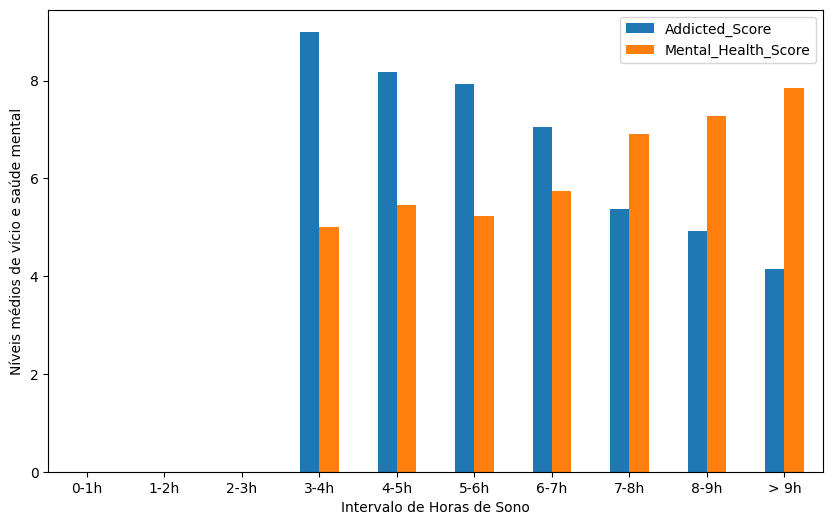

In [ ]:
bins = [0,1,2,3,4,5, 6, 7, 8, 9, 10]
labels = ['0-1h', '1-2h', '2-3h','3-4h', '4-5h', '5-6h', '6-7h', '7-8h', '8-9h', '> 9h']

df['Faixa_Sono'] = pd.cut(df['Sleep_Hours_Per_Night'], bins=bins, labels=labels)
df['Screen_Time'] = pd.cut(df['Avg_Daily_Usage_Hours'], bins=bins, labels=labels)
df_agrupado = df.groupby('Faixa_Sono', observed=False)[['Addicted_Score', 'Mental_Health_Score']].mean()

df_agrupado.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Níveis médios de vício e saúde mental')
plt.xlabel('Intervalo de Horas de Sono')
plt.xticks(rotation=0)
plt.show()

Posteriormente, comparamos as faixas de sono das pessoas com o seu tempo de tela. O que visualmente comprova a sua correlação inversamente proporcional de -0.79.

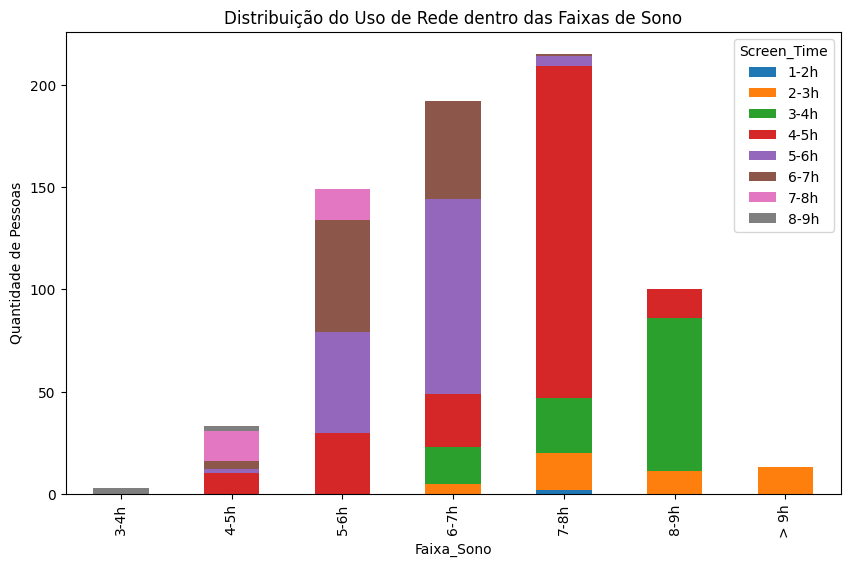

In [ ]:
sleepScreenTimeProportion = pd.crosstab(df['Faixa_Sono'], df['Screen_Time'])
sleepScreenTimeProportion.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.ylabel('Quantidade de Pessoas')
plt.title('Distribuição do Uso de Rede dentro das Faixas de Sono')
plt.show()

Ademais, podemos observar que o uso das redes pode ser uma consequência direta disso, já que dentro das maiores faixas de sono ocorrem as menores faixa de horas de uso e viceversa. Vale ressaltar também o fato assustador que muitas pessoas passam mais tempo em redes sociais e em telas do que dormindo.

# Resultados


**Acurácias dos classificadores**


* Acurácia de classificador knn para vicío: 99,44%
* Acurácia de floresta aleatória para vicío: 99.44%
* Acurácia de floresta aleatória para vicío (sem Mental_Health_Score): 98.31%
* Acurácia de classificador knn para saúde mental: 100%
* Acurácia de floresta aleatória para saúde mental: 99.44%
* Acurácia de floresta aleatória para saúde mental (sem Addicted_Score): 98.87%

**Correlações de impacto das targets**

- Mental_Health_Score e Addicted_Score: -0.94
- Avg_Daily_Usage_Hours e Mental_Health_Score: -0.80
- Avg_Daily_Usage_Hours e Addicted_Score: 0.83
- Affects_Academic_Performance e Addicted_Score: 0.86
- Sleep_Hours_Per_Night e Mental_Health_Score: 0.70
- Sleep_Hours_Per_Night e Addicted_Score: -0.76
- Mental_Health_Score e Conflicts_Over_Social_Media: -0.89
- Conflicts_Over_Social_Media e Addicted_Score: 0.93


**Dados gerais descobertos com Pandas**
- Principais plataformas de pessoas com vício 9: Instagram -> 54.55% e TikTok -> 36.36%
- Principais plataformas de pessoas com vício 2 e 3: LINE -> 70.59% e LinkedIn -> 23.53%
- LINE e LinkedIn possuem as menores médias de vício e as maiores de saúde mental
- Snapchat, TikTok, WhatsApp e Instagram possuem as maiores médias de vício e as menores médias de saúde mental
- Principais países de pessoas com vício 9: USA -> 58.18%
- Principais países de pessoas com vício 2 e 3: Japan -> 70.59%
- Quanto menor o sono, maior o vício e menor a saúde mental
- Quanto maior o sono, melhor a saúde mental e menor o vício

# Conclusões e Discussões

Portanto, com base no processo feito e nos resultados dele, podemos responder os nossos questionamentos iniciais.



- "O vício em redes sociais em jovens está relacionado com problemas saúde mental, horas de sono diárias?"
- "O tipo da rede social influencia no nível dos problemas gerados?"
 - "O nível de saúde mental de um jovem está relacionado com o seu vício nas redes, quantidade de horas por dia de redes sociais, horas de sono diárias e desempenho escolar?"


Os classificadores demonstraram serem extremamente eficientes, mesmo com a remoção da variável de maior influência. Isso nos leva a concluir que as variáveis estão bastante interligadas.

Ao analisarmos a correlação entre as variáveis, isso se comprova, de forma que o perfil da pessoa com vício alto é também de saúde mental baixa, poucas horas de sono diárias, muitas horas de rede por dia, problemas de desempenho acadêmico e conflitos nas redes sociais. Portanto, o vício em redes sociais em jovens está sim relacionado com esses problemas já detalhados.

E, pela correlação, o nível de saúde mental também está relacionado ao vício nas redes, além de outros tipos de características. Assim, também conseguimos formar um perfil para uma pessoa com boa saúde mental, sendo atrelado a baixo vício em redes, altas horas de sono, baixo uso diário de redes sociais,  poucos conflitos nas redes e bom desempenho acadêmico.

Com relação ao tipo de plataforma, podemos concluir que as pessoas com maiores vícios utilizam mais Instagram e Tiktok, plataformas conhecidas pelo seu conteúdo e algoritmo viciante, além da extrema exposição das vidas pessoais, o que pode gerar comparações doentias entre os usuários. Já as pessoas com menores nível de vício costumam usar LINE e LinkedIn. Essa última é conhecida por ser uma plataforma profissional, focada em negócios e empregos. Essas características denunciam uma relação entre o nível do vício e o tipo de plataforma. Como já detalhado anteriormente, Snapchat, TikTok, WhatsApp e Instagram possuem as maiores médias de vício e as menores médias de saúde mental, e LINE e LinkedIn possuem as menores médias de vício e as maiores de saúde mental. Já quando pensamos na pessoa de vício médio, é visto que geralmente as redes mais usadas são do ecossistema da Meta (Facebook, Instagram, WhatsApp) e esta integração pode também ter certa influência no tempo de uso.

Outro dado relevante é o do país mais frequente para os níveis extremos de vício. Começando pelo nível de vício alto, o país mais frequente é Estados Unidos, com 58,18% dos usuários de nível de vício 9. Já para os baixos níveis de vício, o país mais frequente foi o Japão, com 70,59% dos usuários de níveis de vício 2 e 3. Primeiramente, podemos atribuir isso a diferenças culturais entre os dois países e também supor o uso de outras redes que talvez sejam mais populares no Oriente do que às que estamos acostumadas no Ocidente. Segundamente, podemos perceber que a porcentagem de japoneses nos níveis 2 e 3 é a exata mesma porcentagem de pessoas que utilizam a plataforma LINE. Isso se dá pelo fato de LINE ser a plataforma de mensagens de texto mais usual no Japão. Também podemos perceber que dentre pessoas de nível médio, existe uma distribuição equilibrada de países, obtendo grande destaque aos europeus.

Ademais, quando falamos sobre horas dormidas e sono — uma das principais características que afetam a saúde dos indivíduos —, vemos também que o uso das redes influencia negativamente. Primeiramente, pessoas com melhor saúde mental dormem mais, o que pode estar relacionado a outros tipos de condição. Entretanto, quando olhamos que pessoas que passam menos tempo na tela e possuem baixo nível de vício dormem mais, e as que passam mais tempo e possuem alto vício dormem abaixo da média, vemos o claro impacto do uso das redes.

Por fim, concluímos que a nossa hipótese inicial se provou correta, visto que todas as características se relacionam afetando diretamente os níveis de vício e de saúde mental de um jovem.